In [1]:
### importar librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
#### cargar datos 
###cargar datos 
data=pd.read_csv('cuentas_credicel.csv',encoding='latin-1')

/var/folders/6c/rr21_80s11n3cvrghbnb5mz00000gn/T/ipykernel_49111/698553848.py:3: DtypeWarning: Columns (26,31,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('cuentas_credicel.csv',encoding='latin-1')


In [3]:
data.head()

,folio,tag,folio_solicitud,fecha,marca,modelo,plazo,precio,enganche,descuento,...,porc_enganche,porc_tasa,score_buro,razones_buro,semana_actual,codigo_postal,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,3,HDNAWQ3A,30,12/11/2021 19:00,ZTE,Blade A3 2020 RO B,26S,1949.0,780.0,0.0,...,NaN,0.0,0.0,0,0.0,0,NaN,NaN,26.0,NaN
1,4,M418YNR4,33,12/11/2021 19:15,MOTOROLA,LTE XT2097-12 E7I POWER Azul,13S,2999.0,1050.0,0.0,...,NaN,0.0,0.0,0,0.0,0,NaN,NaN,13.0,NaN
2,5,SZ7V3NZT,37,13/11/2021 14:13,ZTE,BLADE A3 2020 Gris,13S,1959.0,490.0,0.0,...,0.0,0.0,0.0,0,0.0,NaN,NaN,74,NaN,NaN
3,6,9I08UIQZ,38,13/11/2021 15:45,ZTE,BLADE A3 2020 Gris,13S,1959.0,490.0,0.0,...,NaN,0.0,0.0,0,0.0,0,NaN,NaN,13.0,NaN
4,7,JMF4LKYU,44,13/11/2021 16:10,MOTOROLA,G10 B,39S,4299.0,1075.0,0.0,...,0.0,0.0,0.0,NaN,NaN,74,NaN,NaN,NaN,NaN


In [4]:
### hacemos una copia del dataframe original
data2 = data.copy()

In [7]:
###nulos 
data2.isnull().sum().sort_values(ascending=False)

Unnamed: 36           22734
Unnamed: 33           21876
Unnamed: 34           21532
Unnamed: 35           20262
semana_actual          4505
razones_buro           4505
status_cuenta          4197
puntos                 3595
fecha_ultimo_pago      3356
fecha_pago_proximo     3356
porc_enganche          2473
riesgo                 2473
codigo_postal           685
empresa                  13
agente_venta              0
descuento                 0
folio_solicitud           0
fecha                     0
marca                     0
modelo                    0
plazo                     0
precio                    0
score_buro                0
porc_tasa                 0
enganche                  0
semana                    0
dis_venta                 0
monto_financiado          0
costo_total               0
monto_accesorios          0
reautorizacion            0
pagos_realizados          0
inversion                 0
tag                       0
fraude                    0
status              

In [11]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22735 entries, 0 to 22734
Data columns (total 37 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   folio               22735 non-null  int64  
 1   tag                 22735 non-null  object 
 2   folio_solicitud     22735 non-null  int64  
 3   fecha               22735 non-null  object 
 4   marca               22735 non-null  object 
 5   modelo              22735 non-null  object 
 6   plazo               22735 non-null  object 
 7   precio              22735 non-null  float64
 8   enganche            22735 non-null  float64
 9   descuento           22735 non-null  float64
 10  semana              22735 non-null  int64  
 11  monto_financiado    22735 non-null  float64
 12  costo_total         22735 non-null  int64  
 13  monto_accesorios    22735 non-null  float64
 14  agente_venta        22735 non-null  object 
 15  dis_venta           22735 non-null  object 
 16  stat

In [8]:
#### nulos fecha_ultimo_pago, fecha_pago_proximo
data2["fecha_ultimo_pago"] = data2["fecha_ultimo_pago"].fillna("01-01-2030 00:00:00") 
data2["fecha_pago_proximo"] = data2["fecha_pago_proximo"].fillna("01-01-2030 00:00:00") 

In [10]:
###nulos 
data2.isnull().sum().sort_values(ascending=False)

Unnamed: 36           22734
Unnamed: 33           21876
Unnamed: 34           21532
Unnamed: 35           20262
semana_actual          4505
razones_buro           4505
status_cuenta          4197
puntos                 3595
porc_enganche          2473
riesgo                 2473
codigo_postal           685
empresa                  13
costo_total               0
semana                    0
folio_solicitud           0
fecha                     0
marca                     0
modelo                    0
plazo                     0
precio                    0
score_buro                0
porc_tasa                 0
enganche                  0
descuento                 0
monto_financiado          0
monto_accesorios          0
fecha_pago_proximo        0
fecha_ultimo_pago         0
reautorizacion            0
pagos_realizados          0
inversion                 0
tag                       0
fraude                    0
status                    0
dis_venta                 0
agente_venta        

In [12]:
### nulos con string Unnamed: 33, Unnamed: 34, semana_actual, razones_buro, status_cuenta, riesgo, codigo_postal, empresa 
data2["Unnamed: 33"] = data2["Unnamed: 33"].fillna("Sin registro")
data2["Unnamed: 34"] = data2["Unnamed: 34"].fillna("Sin registro")
data2["semana_actual"] = data2["semana_actual"].fillna("Sin registro")
data2["razones_buro"] = data2["razones_buro"].fillna("Sin registro")
data2["status_cuenta"] = data2["status_cuenta"].fillna("Sin registro")
data2["riesgo"] = data2["riesgo"].fillna("Sin registro")
data2["codigo_postal"] = data2["codigo_postal"].fillna("Sin registro")
data2["empresa"] = data2["empresa"].fillna("Sin registro")
data2.isnull().sum().sort_values(ascending=False)


Unnamed: 36           22734
Unnamed: 35           20262
puntos                 3595
porc_enganche          2473
reautorizacion            0
fecha_ultimo_pago         0
fecha_pago_proximo        0
status_cuenta             0
riesgo                    0
porc_tasa                 0
inversion                 0
score_buro                0
razones_buro              0
semana_actual             0
codigo_postal             0
Unnamed: 33               0
Unnamed: 34               0
pagos_realizados          0
folio                     0
tag                       0
fraude                    0
folio_solicitud           0
fecha                     0
marca                     0
modelo                    0
plazo                     0
precio                    0
enganche                  0
descuento                 0
semana                    0
monto_financiado          0
costo_total               0
monto_accesorios          0
agente_venta              0
dis_venta                 0
status              

In [13]:
### nulos de Unnamed: 36, Unnamed: 35, puntos, porc_enganche con 0
data2["Unnamed: 36"]=data2["Unnamed: 36"].fillna(round(data2["Unnamed: 36"].mean(),1))
data2["Unnamed: 35"]=data2["Unnamed: 35"].fillna(round(data2["Unnamed: 35"].mean(),1))
data2["puntos"]=data2["puntos"].fillna(round(data2["puntos"].mean(),1))
data2["porc_enganche"]=data2["porc_enganche"].fillna(round(data2["porc_enganche"].mean(),1))
data2.isnull().sum().sort_values(ascending=False)


folio                 0
inversion             0
reautorizacion        0
fecha_ultimo_pago     0
fecha_pago_proximo    0
status_cuenta         0
puntos                0
riesgo                0
porc_enganche         0
porc_tasa             0
score_buro            0
razones_buro          0
semana_actual         0
codigo_postal         0
Unnamed: 33           0
Unnamed: 34           0
Unnamed: 35           0
pagos_realizados      0
empresa               0
tag                   0
fraude                0
folio_solicitud       0
fecha                 0
marca                 0
modelo                0
plazo                 0
precio                0
enganche              0
descuento             0
semana                0
monto_financiado      0
costo_total           0
monto_accesorios      0
agente_venta          0
dis_venta             0
status                0
Unnamed: 36           0
dtype: int64

In [14]:
data2.isnull().sum().sum()

0

In [15]:
####crar dos dataframes cualitativos y cuantitativos
cualitativas = data2[[
    "tag",
    "fecha",
    "marca",
    "modelo",
    "plazo",
    "agente_venta",
    "dis_venta",
    "empresa",
    "fecha_ultimo_pago",
    "fecha_pago_proximo",
    "status_cuenta",
    "riesgo",
    "razones_buro",
    "semana_actual",
    "codigo_postal",
    "Unnamed: 33",
    "Unnamed: 34"
]]
cuantitativas = data2[[
    "folio",
    "folio_solicitud",
    "semana",
    "precio",
    "enganche",
    "descuento",
    "monto_financiado",
    "costo_total",
    "monto_accesorios",
    "status",
    "fraude",
    "inversion",
    "pagos_realizados",
    "reautorizacion",
    "puntos",
    "porc_enganche",
    "porc_tasa",
    "score_buro",
    "Unnamed: 35",
    "Unnamed: 36"
]]

In [16]:
cualitativas.head()

,tag,fecha,marca,modelo,plazo,agente_venta,dis_venta,empresa,fecha_ultimo_pago,fecha_pago_proximo,status_cuenta,riesgo,razones_buro,semana_actual,codigo_postal,Unnamed: 33,Unnamed: 34
0,HDNAWQ3A,12/11/2021 19:00,ZTE,Blade A3 2020 RO B,26S,Sintia Verenice Tenorio Perez E,mic0437,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,Sin registro,Sin registro,0,0.0,0,Sin registro,Sin registro
1,M418YNR4,12/11/2021 19:15,MOTOROLA,LTE XT2097-12 E7I POWER Azul,13S,Alvaro Rafael Pascual,mic015,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,Sin registro,Sin registro,0,0.0,0,Sin registro,Sin registro
2,SZ7V3NZT,13/11/2021 14:13,ZTE,BLADE A3 2020 Gris,13S,Sintia Verenice Tenorio Perez E,mic0437,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,Sin registro,Cancelado,0,0.0,Sin registro,Sin registro,74
3,9I08UIQZ,13/11/2021 15:45,ZTE,BLADE A3 2020 Gris,13S,Luz Aylin Hernandez Lopez1,mic0748,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,Sin registro,Sin registro,0,0.0,0,Sin registro,Sin registro
4,JMF4LKYU,13/11/2021 16:10,MOTOROLA,G10 B,39S,Sintia Verenice Tenorio Perez E,mic0437,microtec,05/03/2022 00:00,12/03/2022 00:00,Mora,0,Sin registro,Sin registro,74,Sin registro,Sin registro


In [17]:
cuantitativas.head()

,folio,folio_solicitud,semana,precio,enganche,descuento,monto_financiado,costo_total,monto_accesorios,status,fraude,inversion,pagos_realizados,reautorizacion,puntos,porc_enganche,porc_tasa,score_buro,Unnamed: 35,Unnamed: 36
0,3,30,81,1949.0,780.0,0.0,1169.0,2106,0.0,2,0,0,0,0,14.1,0.9,0.0,0.0,26.0,93080.0
1,4,33,225,2999.0,1050.0,0.0,1949.0,2925,0.0,2,0,0,0,0,14.1,0.9,0.0,0.0,13.0,93080.0
2,5,37,170,1959.0,490.0,0.0,1469.0,2210,0.0,3,0,0,0,0,14.1,0.0,0.0,0.0,9961.3,93080.0
3,6,38,170,1959.0,490.0,0.0,1469.0,2210,0.0,2,0,0,0,0,14.1,0.9,0.0,0.0,13.0,93080.0
4,7,44,178,4299.0,1075.0,0.0,3224.0,6942,0.0,1,0,0,0,0,0.0,0.0,0.0,0.0,9961.3,93080.0


<Figure size 1500x800 with 0 Axes>

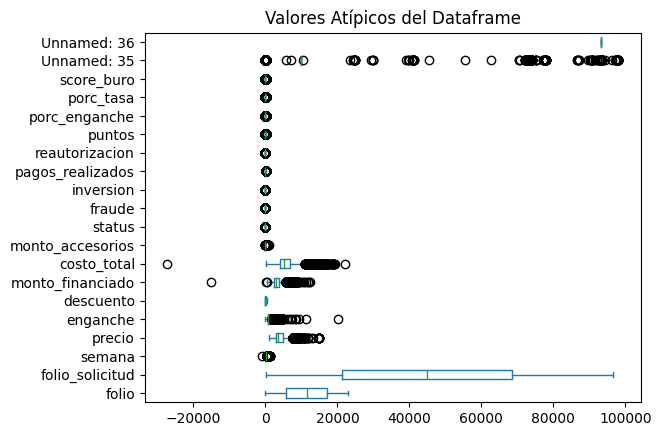

In [18]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [19]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido folio                31323.107698
folio_solicitud     127723.906961
semana                 541.287392
precio                8081.558082
enganche              2356.496845
descuento              478.215020
monto_financiado      6366.317810
costo_total          12857.588246
monto_accesorios       191.260880
status                   2.611178
fraude                   0.864131
inversion                1.511599
pagos_realizados        39.306132
reautorizacion           0.578086
puntos                  42.386431
porc_enganche           18.135840
porc_tasa               24.630537
score_buro              13.931194
Unnamed: 35          36884.839233
Unnamed: 36          93080.000000
dtype: float64
Limite inferior permitido folio               -8301.055796
folio_solicitud    -36023.715538
semana                -65.792692
precio                -87.484900
enganche             -503.622066
descuento            -321.263535
monto_financiado     -214.044583
costo_total         -1

In [20]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3

,folio,folio_solicitud,semana,precio,enganche,descuento,monto_financiado,costo_total,monto_accesorios,status,fraude,inversion,pagos_realizados,reautorizacion,puntos,porc_enganche,porc_tasa,score_buro,Unnamed: 35,Unnamed: 36
0,3,30,81.0,1949.0,780.0,0.0,1169.0,2106.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,26.0,93080.0
1,4,33,225.0,2999.0,1050.0,0.0,1949.0,2925.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
2,5,37,170.0,1959.0,490.0,0.0,1469.0,2210.0,0.0,NaN,0.0,0,0.0,0.0,14.1,0.0,0.00,0.0,9961.3,93080.0
3,6,38,170.0,1959.0,490.0,0.0,1469.0,2210.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
4,7,44,178.0,4299.0,1075.0,0.0,3224.0,6942.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.00,0.0,9961.3,93080.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22730,22967,96502,211.0,3349.0,297.0,0.0,3052.0,5486.0,0.0,1.0,0.0,0,0.0,0.0,14.1,NaN,-1.13,0.0,9961.3,93080.0
22731,22968,96479,200.0,4100.0,1209.0,0.0,2891.0,5200.0,0.0,1.0,0.0,0,0.0,0.0,14.1,NaN,7.48,0.0,9961.3,93080.0
22732,22969,96442,256.0,4849.0,1152.0,0.0,3697.0,6656.0,0.0,1.0,0.0,0,0.0,0.0,14.1,NaN,0.75,0.0,9961.3,93080.0
22733,22970,96536,386.0,NaN,NaN,0.0,NaN,NaN,0.0,1.0,0.0,0,0.0,0.0,14.1,NaN,-0.14,0.0,9961.3,93080.0


In [21]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data3.isnull().sum()
valores_nulos

folio                  0
folio_solicitud        0
semana               362
precio               110
enganche             292
descuento             17
monto_financiado     182
costo_total          290
monto_accesorios     617
status               154
fraude              1701
inversion              0
pagos_realizados     184
reautorizacion       774
puntos               954
porc_enganche        486
porc_tasa            899
score_buro           582
Unnamed: 35          297
Unnamed: 36            0
dtype: int64

In [22]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.mean(),1))
data_clean

,folio,folio_solicitud,semana,precio,enganche,descuento,monto_financiado,costo_total,monto_accesorios,status,fraude,inversion,pagos_realizados,reautorizacion,puntos,porc_enganche,porc_tasa,score_buro,Unnamed: 35,Unnamed: 36
0,3,30,81.0,1949.0,780.0,0.0,1169.0,2106.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,26.0,93080.0
1,4,33,225.0,2999.0,1050.0,0.0,1949.0,2925.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
2,5,37,170.0,1959.0,490.0,0.0,1469.0,2210.0,0.0,1.2,0.0,0,0.0,0.0,14.1,0.0,0.00,0.0,9961.3,93080.0
3,6,38,170.0,1959.0,490.0,0.0,1469.0,2210.0,0.0,2.0,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
4,7,44,178.0,4299.0,1075.0,0.0,3224.0,6942.0,0.0,1.0,0.0,0,0.0,0.0,0.0,0.0,0.00,0.0,9961.3,93080.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22730,22967,96502,211.0,3349.0,297.0,0.0,3052.0,5486.0,0.0,1.0,0.0,0,0.0,0.0,14.1,0.2,-1.13,0.0,9961.3,93080.0
22731,22968,96479,200.0,4100.0,1209.0,0.0,2891.0,5200.0,0.0,1.0,0.0,0,0.0,0.0,14.1,0.2,7.48,0.0,9961.3,93080.0
22732,22969,96442,256.0,4849.0,1152.0,0.0,3697.0,6656.0,0.0,1.0,0.0,0,0.0,0.0,14.1,0.2,0.75,0.0,9961.3,93080.0
22733,22970,96536,386.0,3969.2,897.6,0.0,3043.8,5588.6,0.0,1.0,0.0,0,0.0,0.0,14.1,0.2,-0.14,0.0,9961.3,93080.0


In [23]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

folio               0
folio_solicitud     0
semana              0
precio              0
enganche            0
descuento           0
monto_financiado    0
costo_total         0
monto_accesorios    0
status              0
fraude              0
inversion           0
pagos_realizados    0
reautorizacion      0
puntos              0
porc_enganche       0
porc_tasa           0
score_buro          0
Unnamed: 35         0
Unnamed: 36         0
dtype: int64

In [25]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios

,tag,fecha,marca,modelo,plazo,agente_venta,dis_venta,empresa,fecha_ultimo_pago,fecha_pago_proximo,...,fraude,inversion,pagos_realizados,reautorizacion,puntos,porc_enganche,porc_tasa,score_buro,Unnamed: 35,Unnamed: 36
0,HDNAWQ3A,12/11/2021 19:00,ZTE,Blade A3 2020 RO B,26S,Sintia Verenice Tenorio Perez E,mic0437,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,...,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,26.0,93080.0
1,M418YNR4,12/11/2021 19:15,MOTOROLA,LTE XT2097-12 E7I POWER Azul,13S,Alvaro Rafael Pascual,mic015,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,...,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
2,SZ7V3NZT,13/11/2021 14:13,ZTE,BLADE A3 2020 Gris,13S,Sintia Verenice Tenorio Perez E,mic0437,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,...,0.0,0,0.0,0.0,14.1,0.0,0.00,0.0,9961.3,93080.0
3,9I08UIQZ,13/11/2021 15:45,ZTE,BLADE A3 2020 Gris,13S,Luz Aylin Hernandez Lopez1,mic0748,microtec,01-01-2030 00:00:00,01-01-2030 00:00:00,...,0.0,0,0.0,0.0,14.1,0.9,0.00,0.0,13.0,93080.0
4,JMF4LKYU,13/11/2021 16:10,MOTOROLA,G10 B,39S,Sintia Verenice Tenorio Perez E,mic0437,microtec,05/03/2022 00:00,12/03/2022 00:00,...,0.0,0,0.0,0.0,0.0,0.0,0.00,0.0,9961.3,93080.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22730,92KQVRIX,18/04/2023 18:45,Motorola,Moto E13,26S,Mildred Asuncion Arguello Caamal,svc044,servicel,18/04/2023 18:45,25/04/2023 00:00,...,0.0,0,0.0,0.0,14.1,0.2,-1.13,0.0,9961.3,93080.0
22731,NWB2EA8J,18/04/2023 18:46,Motorola,Moto E22i,26S,Maria Guadalupe Vargas Lopez,PXC004,pixelulares,18/04/2023 18:46,25/04/2023 00:00,...,0.0,0,0.0,0.0,14.1,0.2,7.48,0.0,9961.3,93080.0
22732,VDTRJ2W6,18/04/2023 18:47,Samsung,A13,26S,Nicolás Jiménez Sánchez,gph008,Sin registro,18/04/2023 18:47,25/04/2023 00:00,...,0.0,0,0.0,0.0,14.1,0.2,0.75,0.0,9961.3,93080.0
22733,PETLF56C,18/04/2023 18:49,Samsung,A53 5G,39S,Maribel Ulibarri Medina,gph014,grupoph,18/04/2023 18:49,25/04/2023 00:00,...,0.0,0,0.0,0.0,14.1,0.2,-0.14,0.0,9961.3,93080.0


In [27]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("evaluacionpt2.csv")